# Data Info + Preprocessing & Cleaning

## Data Info

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("combined.csv")

In [2]:
print("Shape:", df.shape)

Shape: (26292, 32)


In [3]:
print("Columns:", df.columns)

Columns: Index(['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PTS', 'Awards', 'Season', '3P', '3PA', '3P%', '2P', '2PA',
       '2P%', 'eFG%'],
      dtype='object')


# NBA Column Definitions

## Player Information
- **Rk (Rank)**: Player's rank in the table based on overall listing.
- **Player**: Player's name.
- **Age**: Player's age during the season.
- **Team**: Team abbreviation.
- **Pos (Position)**: Player's position (PG = Point Guard, SG = Shooting Guard, SF = Small Forward, PF = Power Forward, C = Center).

## Playing Time
- **G (Games Played)**: Number of games the player appeared in.
- **GS (Games Started)**: Number of games the player started.
- **MP (Minutes Played)**: Average minutes played per game.

## Shooting

### Field Goals
- **FG (Field Goals Made)**: Average number of made shots per game (excluding free throws).
- **FGA (Field Goals Attempted)**: Average number of shot attempts per game.
- **FG% (Field Goal Percentage)**: Shooting efficiency calculated as FG / FGA.

### Free Throws
- **FT (Free Throws Made)**: Average number of free throws made per game.
- **FTA (Free Throws Attempted)**: Average number of free throw attempts.
- **FT% (Free Throw Percentage)**: Free throw success rate.

### Three-Point Shots
- **3P (3-Point Made)**: Average number of three-point shots made per game.
- **3PA (3-Point Attempted)**: Average number of three-point attempts.
- **3P% (3-Point Percentage)**: Three-point shooting efficiency.

### Two-Point Shots
- **2P (2-Point Made)**: Average number of two-point shots made per game.
- **2PA (2-Point Attempted)**: Average number of two-point attempts.
- **2P% (2-Point Percentage)**: Two-point shooting efficiency.

### Advanced Shooting
- **eFG% (Effective Field Goal Percentage)**: Adjusted field goal percentage that accounts for the added value of three-point shots.  
  Formula: (FG + 0.5 × 3P) / FGA  
  Since three-point shots are worth more points than two-point shots, they are given extra weight in this metric.

## Rebounding
- **ORB (Offensive Rebounds)**: Average rebounds collected on the offensive end.  
  It happens when a player retrieves the ball after a missed shot by their own team, giving the team another scoring opportunity.

- **DRB (Defensive Rebounds)**: Average rebounds collected on the defensive end.  
  It happens when a player retrieves the ball after a missed shot by the opposing team, ending their possession.

- **TRB (Total Rebounds)**: Total rebounds per game (ORB + DRB).  
  It represents the player's overall rebounding performance.

  
## Playmaking and Defense
- **AST (Assists)**: Average number of assists per game.
- **STL (Steals)**: Average number of steals per game.
- **BLK (Blocks)**: Average number of blocked shots per game.

## Turnovers and Fouls

- **TOV (Turnovers)**:  
  Average number of times a player loses possession of the ball.  
  This can happen due to bad passes, ball handling mistakes, or violations (e.g., traveling).

- **PF (Personal Fouls)**:  
  Average number of fouls committed by a player against opponents.  
  These can result in free throws or penalties, and too many fouls may lead to fouling out.

## Scoring
- **PTS (Points)**: Average number of points scored per game.

## Additional Information
- **Awards**: Honors or awards received during the season (e.g., MVP, All-Star).
- **Season**: Season year (added manually during data collection).

## Note
All statistics are per-game averages, not totals for the season.

In [4]:
print("Info:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26292 entries, 0 to 26291
Data columns (total 32 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      26241 non-null  float64
 1   Player  26292 non-null  object 
 2   Age     26241 non-null  float64
 3   Team    26241 non-null  object 
 4   Pos     26241 non-null  object 
 5   G       26241 non-null  float64
 6   GS      24404 non-null  float64
 7   MP      26241 non-null  float64
 8   FG      26241 non-null  float64
 9   FGA     26241 non-null  float64
 10  FG%     26155 non-null  float64
 11  FT      26241 non-null  float64
 12  FTA     26241 non-null  float64
 13  FT%     25109 non-null  float64
 14  ORB     26241 non-null  float64
 15  DRB     26241 non-null  float64
 16  TRB     26241 non-null  float64
 17  AST     26241 non-null  float64
 18  STL     26241 non-null  float64
 19  BLK     26241 non-null  float64
 20  TOV     25348 non-null  float64
 21  PF      26241 non-null  float64
 22

In [5]:
print("First 5 rows:")
print(df.head())

First 5 rows:
    Rk               Player   Age Team Pos     G  GS    MP    FG   FGA  ...  \
0  1.0           Bob McAdoo  23.0  BUF   C  82.0 NaN  43.2  13.4  26.1  ...   
1  2.0           Rick Barry  30.0  GSW  SF  80.0 NaN  40.4  12.9  27.7  ...   
2  3.0  Kareem Abdul-Jabbar  27.0  MIL   C  65.0 NaN  42.3  12.5  24.4  ...   
3  4.0       Tiny Archibald  26.0  KCO  PG  82.0 NaN  39.6   9.3  20.3  ...   
4  5.0        Charlie Scott  26.0  PHO  PG  69.0 NaN  37.6  10.2  23.1  ...   

    PTS         Awards  Season  3P  3PA  3P%  2P  2PA  2P%  eFG%  
0  34.5  MVP-1,AS,NBA1    1975 NaN  NaN  NaN NaN  NaN  NaN   NaN  
1  30.6  MVP-4,AS,NBA1    1975 NaN  NaN  NaN NaN  NaN  NaN   NaN  
2  30.0  MVP-5,AS,DEF1    1975 NaN  NaN  NaN NaN  NaN  NaN   NaN  
3  26.5  MVP-6,AS,NBA1    1975 NaN  NaN  NaN NaN  NaN  NaN   NaN  
4  24.3             AS    1975 NaN  NaN  NaN NaN  NaN  NaN   NaN  

[5 rows x 32 columns]


In [6]:
# Awards has too many missing values -> not useful
# Some % columns have missing -> due to no attempts
print("Missing values:")
print(df.isna().sum())

Missing values:
Rk           51
Player        0
Age          51
Team         51
Pos          51
G            51
GS         1888
MP           51
FG           51
FGA          51
FG%         137
FT           51
FTA          51
FT%        1183
ORB          51
DRB          51
TRB          51
AST          51
STL          51
BLK          51
TOV         944
PF           51
PTS          51
Awards    23740
Season        0
3P         1676
3PA        1676
3P%        5510
2P         1676
2PA        1676
2P%        1851
eFG%       1762
dtype: int64


In [7]:
df.dtypes

Rk        float64
Player     object
Age       float64
Team       object
Pos        object
G         float64
GS        float64
MP        float64
FG        float64
FGA       float64
FG%       float64
FT        float64
FTA       float64
FT%       float64
ORB       float64
DRB       float64
TRB       float64
AST       float64
STL       float64
BLK       float64
TOV       float64
PF        float64
PTS       float64
Awards     object
Season      int64
3P        float64
3PA       float64
3P%       float64
2P        float64
2PA       float64
2P%       float64
eFG%      float64
dtype: object

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Data Description: ")
df.describe()

Data Description: 


,Rk,Age,G,GS,MP,FG,FGA,FG%,FT,FTA,...,PF,PTS,Season,3P,3PA,3P%,2P,2PA,2P%,eFG%
count,26241.000000,26241.000000,26241.000000,24404.000000,26241.000000,26241.000000,26241.000000,26155.000000,26241.000000,26241.000000,...,26241.000000,26241.000000,26292.000000,24616.000000,24616.000000,20782.000000,24616.000000,24616.000000,24441.000000,24530.000000
mean,225.527876,26.617431,48.042872,22.613752,19.795267,3.101955,6.833310,0.440100,1.504516,2.009405,...,1.883331,8.176525,2003.451316,0.501276,1.453421,0.265873,2.561801,5.301377,0.469490,0.474826
std,133.911547,4.009033,26.659468,28.016553,10.060671,2.265389,4.680351,0.100783,1.391131,1.754477,...,0.880060,6.041062,14.320570,0.680249,1.799637,0.169628,2.048213,4.021268,0.111042,0.106252
min,1.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1975.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,114.000000,24.000000,24.000000,0.000000,11.500000,1.300000,3.200000,0.402000,0.500000,0.800000,...,1.200000,3.500000,1992.000000,0.000000,0.000000,0.167000,1.000000,2.300000,0.429000,0.439000
50%,219.000000,26.000000,52.000000,7.000000,19.100000,2.500000,5.700000,0.444000,1.100000,1.500000,...,1.900000,6.600000,2005.000000,0.200000,0.700000,0.311000,2.000000,4.100000,0.475000,0.484000
75%,326.000000,29.000000,74.000000,42.000000,28.000000,4.400000,9.500000,0.488000,2.000000,2.700000,...,2.500000,11.500000,2016.000000,0.800000,2.400000,0.369000,3.600000,7.400000,0.517000,0.524000
max,605.000000,44.000000,87.000000,83.000000,44.500000,13.400000,28.000000,1.000000,10.300000,13.100000,...,6.000000,37.100000,2025.000000,5.300000,13.200000,1.000000,13.200000,27.000000,1.000000,1.500000


## Data Preprocessing

In [10]:
# Remove repeated header rows that appear inside the table
df = df[df["Rk"] != "Rk"]

In [11]:
df = df.drop(columns=["Player", "Rk", "Awards"])

In [12]:
# The column may contain string values instead of numeric ones,
# so we convert the FT% column to numeric.
# "coerce" replaces invalid values with NaN.
df["FT%"] = pd.to_numeric(df["FT%"], errors="coerce")

# Create a binary column: 1 if FT% > 0.75, else 0
# (df["FT%"] > 0.75) returns True/False, and astype(int) converts True -> 1 and False -> 0
df["GoodFT"] = (df["FT%"] > 0.75).astype(int)

In [13]:
# Drop FT and FT% columns to remove redundant information after feature engineering
df = df.drop(columns=["FT", "FT%"])
df = df.dropna()
print(df.isna().sum())

Age       0
Team      0
Pos       0
G         0
GS        0
MP        0
FG        0
FGA       0
FG%       0
FTA       0
ORB       0
DRB       0
TRB       0
AST       0
STL       0
BLK       0
TOV       0
PF        0
PTS       0
Season    0
3P        0
3PA       0
3P%       0
2P        0
2PA       0
2P%       0
eFG%      0
GoodFT    0
dtype: int64


## Create Target and remove unused features

In [14]:
features = [
    "Pos", "G", "GS", "MP", "FG%", "3P%", "2P%", "eFG%", 
    "TRB", "AST", "STL", "BLK", "TOV", "PF"
]

df = df[features + ["GoodFT"]]

In [15]:
df = pd.get_dummies(df, columns=["Pos"], drop_first=True)

In [16]:
df = df.apply(lambda col: pd.to_numeric(col, errors="coerce"))

In [17]:
df

,G,GS,MP,FG%,3P%,2P%,eFG%,TRB,AST,STL,BLK,TOV,PF,GoodFT,Pos_PF,Pos_PG,Pos_SF,Pos_SG
1633,78.0,78.0,36.1,0.519,0.200,0.523,0.520,7.4,4.6,2.2,1.8,3.6,2.7,1,False,False,True,False
1634,82.0,82.0,38.3,0.502,0.000,0.504,0.502,14.5,1.8,1.0,1.3,3.7,2.6,0,False,False,False,False
1636,82.0,82.0,35.8,0.505,0.333,0.506,0.506,8.8,2.4,1.1,0.7,2.0,2.3,1,False,False,False,False
1639,82.0,82.0,34.2,0.523,0.000,0.525,0.523,7.2,1.1,0.9,0.9,2.1,3.2,1,False,False,True,False
1640,82.0,82.0,36.2,0.482,0.194,0.489,0.484,3.4,4.8,2.4,0.5,2.2,2.0,1,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26278,5.0,0.0,1.6,0.167,0.000,0.333,0.167,0.0,0.2,0.0,0.0,0.2,0.4,1,False,False,False,True
26280,6.0,0.0,3.5,0.000,0.000,0.000,0.000,0.5,0.2,0.0,0.0,0.2,0.7,0,False,False,True,False
26282,1.0,0.0,8.0,0.000,0.000,0.000,0.000,1.0,1.0,0.0,0.0,0.0,0.0,0,False,False,False,True
26284,2.0,0.0,5.0,0.000,0.000,0.000,0.000,0.5,1.5,0.0,0.0,0.0,1.0,0,False,False,False,True


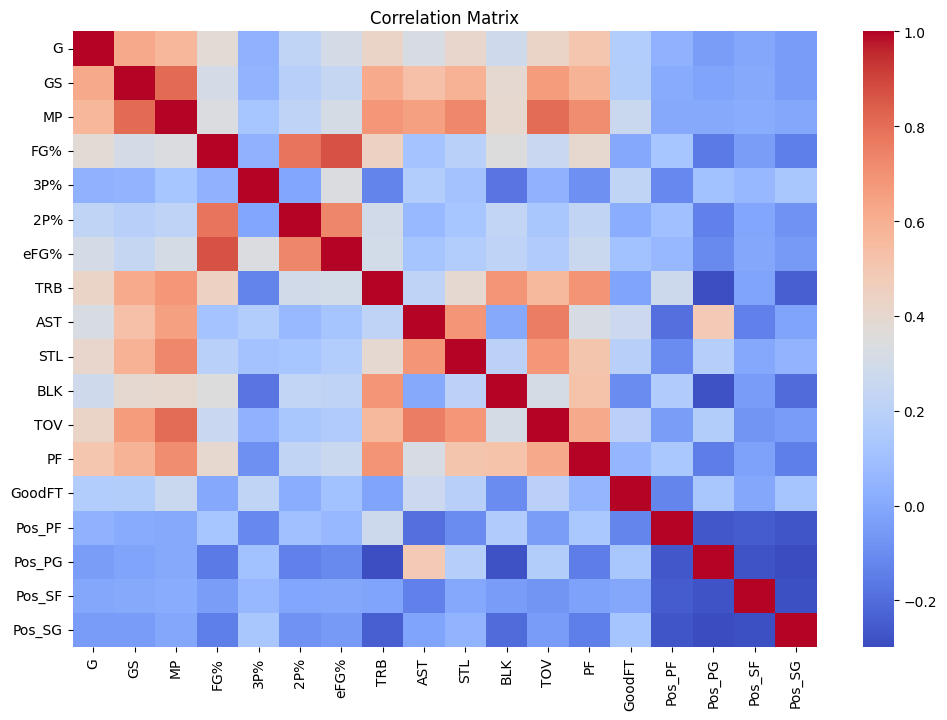

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

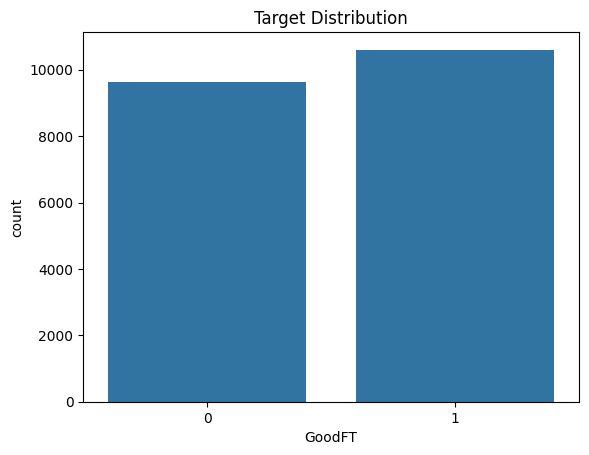

In [19]:
sns.countplot(x="GoodFT", data=df)
plt.title("Target Distribution")
plt.show()

In [20]:
X = df.drop("GoodFT", axis=1)
y = df["GoodFT"]

In [21]:
df

,G,GS,MP,FG%,3P%,2P%,eFG%,TRB,AST,STL,BLK,TOV,PF,GoodFT,Pos_PF,Pos_PG,Pos_SF,Pos_SG
1633,78.0,78.0,36.1,0.519,0.200,0.523,0.520,7.4,4.6,2.2,1.8,3.6,2.7,1,False,False,True,False
1634,82.0,82.0,38.3,0.502,0.000,0.504,0.502,14.5,1.8,1.0,1.3,3.7,2.6,0,False,False,False,False
1636,82.0,82.0,35.8,0.505,0.333,0.506,0.506,8.8,2.4,1.1,0.7,2.0,2.3,1,False,False,False,False
1639,82.0,82.0,34.2,0.523,0.000,0.525,0.523,7.2,1.1,0.9,0.9,2.1,3.2,1,False,False,True,False
1640,82.0,82.0,36.2,0.482,0.194,0.489,0.484,3.4,4.8,2.4,0.5,2.2,2.0,1,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26278,5.0,0.0,1.6,0.167,0.000,0.333,0.167,0.0,0.2,0.0,0.0,0.2,0.4,1,False,False,False,True
26280,6.0,0.0,3.5,0.000,0.000,0.000,0.000,0.5,0.2,0.0,0.0,0.2,0.7,0,False,False,True,False
26282,1.0,0.0,8.0,0.000,0.000,0.000,0.000,1.0,1.0,0.0,0.0,0.0,0.0,0,False,False,False,True
26284,2.0,0.0,5.0,0.000,0.000,0.000,0.000,0.5,1.5,0.0,0.0,0.0,1.0,0,False,False,False,True


In [22]:
df.to_csv("cleaned_data.csv", index=False)